**<font color=skyblue>機器學習常見的三種監督式分類器（Supervised Classification）</font>**

分類器（Classifiers）
- 多元羅吉斯回歸 Multinomial Logistic Regression (LR)
- 支援向量機 Support Vector Machine (SVM)
- 類神經網路 artificial Neural Network (ANN)

分類資料
- wine.xlsx
- groups: 13
- original data vs. principal components
- split into training data and testing data



參考講義：
https://ntpuccw.blog/sml-lesson-8-%e6%b7%ba%e5%ba%a6%e6%a9%9f%e5%99%a8%e5%ad%b8%e7%bf%92%ef%bc%9a%e5%88%86%e9%a1%9e%e5%99%a8%e7%9a%84%e5%8e%9f%e7%90%86%e8%88%87%e8%a9%95%e6%af%94%e5%af%a6%e9%a9%97/
<hr>

<font color=yellow>Import Basic Packages</font>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

<font color=yellow>資料準備</font>

In [18]:
# Read data
df = pd.read_excel('data/Wine.xlsx')
X = np.array(df.iloc[:, :-1]) # 排除最後一欄標籤 N x p
y = np.array(df.iloc[:, -1]) # label N x 1

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30)

# Standardize data
scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.transform(X_test)

# print training and testing data shapes
print("Training data shape:", X_train_.shape)
print("Testing data shape:", X_test_.shape)

Training data shape: (124, 13)
Testing data shape: (54, 13)


<font color=yellow>LogisticRegression on original data</font>

- 了解 LogisticRegression 的重要參數對結果的影響，譬如 C：Inverse of regularization strength。
- 嘗試不同的演算法 solvers：{‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}.
- 了解對評估分群能力的指標： precision, recall, f1-score

precision = $\frac{TP}{TP+FP}$, 
recall = $\frac{TP}{TP+FN}$, 
F1-score = $2\frac{precision\cdot recall}{precision + recall}$


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

opts = dict(C=1.0, tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs'  # 'lbfgs' is the default
# solver = 'liblinear'
# solver = 'newton-cg'
# clf_original = LogisticRegression(solver = 'lbfgs', tol = 1e-6, max_iter = int(1e6), verbose=True)
clf_LR_original = LogisticRegression(solver = solver, **opts)
clf_LR_original.fit(X_train_, y_train) # input data must be (n_samples x n_features)
y_pred = clf_LR_original.predict(X_test_) # predict class labels for samples in X_test_
# print training score
print(f"Training score = {accuracy_score(y_train, clf_LR_original.predict(X_train_)):.2%}\n")
# print testing score
print(f"Testing score = {accuracy_score(y_test, y_pred):.2%}\n")
print(f"Testing score = {clf_LR_original.score(X_test_, y_test):.2%}\n")
print("Classification report: Original data\n")
print(classification_report(y_test, y_pred))

Training score = 100.00%

Testing score = 98.15%

Testing score = 98.15%

Classification report: Original data

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        24
           2       1.00      0.94      0.97        17
           3       0.93      1.00      0.96        13

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



<font color=yellow>LogisticRegression on principal components</font>


In [13]:
from sklearn.decomposition import PCA

q = 2
pca = PCA(n_components = q).fit(X_train_)
Z_train = pca.transform(X_train_)
Z_test = pca.transform(X_test_)
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs'  # 'lbfgs' is default; 
# solver = 'liblinear'
# solver = 'newton-cg'
# clf_LR = LogisticRegression(solver = 'lbfgs', tol = 1e-6, max_iter = int(1e6), verbose=1)
clf_PCA = LogisticRegression(solver = solver, **opts)
clf_PCA.fit(Z_train, y_train) # input data must be (n_samples x n_features)
y_pred = clf_PCA.predict(Z_test)

print(f"Training score: {accuracy_score(y_train, clf_PCA.predict(Z_train)):.2%}\n")
# print testing score
print(f"Testing score: {clf_PCA.score(Z_test, y_test):.2%}\n")
print(f"Classification report: PCA with {q} components\n")
print(classification_report(y_test, y_pred))

Training score: 95.97%

Testing score: 96.30%

Classification report: PCA with 2 components

              precision    recall  f1-score   support

           1       0.96      0.96      0.96        24
           2       0.94      0.94      0.94        17
           3       1.00      1.00      1.00        13

    accuracy                           0.96        54
   macro avg       0.97      0.97      0.97        54
weighted avg       0.96      0.96      0.96        54



<hr>
<font color=orange>練習：製作副程式以方便比較 original data vs principal components 的測試結果。譬如，將結果安排在同一個表格。
<hr>

<font color=yellow>Use LogisticRegressionCV: Logistic Regression + Cross Validation</font>

- Cross Validation: performs cross‑validated hyperparameter tuning over Cs and l1_ratios and then refits the best model.
- Cs: the inverse of regularization strength.
- li_ratio: mixing parameter between L1 and L2 penalties.

In [14]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score

opts = dict(l1_ratios=(0,), tol = 1e-6, max_iter = int(1e6), verbose=1,\
            use_legacy_attributes=True) # use_legacy_attributes=True is needed to avoid FutureWarning: The attribute `C_` is deprecated in favor of `Cs_` and will be removed in v1.3. To access the best C value, use `clf_originalCV.Cs_[0]` instead of `clf_originalCV.C_[0]`.
solver = 'lbfgs'  # 'lbfgs' is the default
# solver = 'liblinear'
# solver = 'newton-cg'
Cs = np.logspace(-4, 4, 20) # Cs = np.logspace(-5, 5, 20) --- IGNORE ---
clf_originalCV = LogisticRegressionCV(solver = solver, Cs = Cs, **opts)
clf_originalCV.fit(X_train_, y_train) # input data must be (n_samples x n_features)
y_pred = clf_originalCV.predict(X_test_)
# print training score
print(f"Training score = {accuracy_score(y_train, clf_originalCV.predict(X_train_)):.2%}\n")
# print testing score
print(f"Testing score = {accuracy_score(y_test, y_pred):.2%}\n")
print(f"Testing score = {clf_originalCV.score(X_test_, y_test):.2%}\n")
print("Classification report: Original data with CV\n")
print(classification_report(y_test, y_pred))
# print the best C value found by CV
print(f"Best C value found by CV: {clf_originalCV.C_[0]:.4f}\n")
# print the best l1_ratio value found by CV
print(f"Best l1_ratio value found by CV: {clf_originalCV.l1_ratio_[0]:.4f}\n")


Training score = 100.00%

Testing score = 98.15%

Testing score = 98.15%

Classification report: Original data with CV

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        24
           2       1.00      0.94      0.97        17
           3       0.93      1.00      0.96        13

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Best C value found by CV: 11.2884

Best l1_ratio value found by CV: 0.0000



[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


<hr>
<font color=yellow>SVM on original data</font>

- 了解 SVC 的重要參數對結果的影響，譬如 
    - C：the inverse of the regularization strength。
    - decision function shape: ovr (one vs rest), ovo (one vs one) 
- 嘗試不同的核 kernel: linear, poly, rbf, sigmoid, precomputed

In [19]:
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report

C = 1 # SVM regularization parameter
opts = dict(C = C, tol = 1e-6, max_iter = int(1e6), \
            decision_function_shape = 'ovo', verbose=1)

clf_svm = SVC(kernel='linear', **opts)
# clf_svm = SVC(kernel='rbf', gamma=0.2, **opts)
# clf_svm = SVC(kernel='poly', degree=3, gamma='auto', **opts)
# clf_svm = LinearSVC(**opts) # one vs the rest
clf_svm.fit(X_train_, y_train)
predictions = clf_svm.predict(X_test_)
print(classification_report(y_test, predictions))

[LibSVM]              precision    recall  f1-score   support

           1       1.00      1.00      1.00        17
           2       1.00      0.95      0.98        21
           3       0.94      1.00      0.97        16

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



<hr>
<font color=yellow>ANN on original data</font>

關注參數的選擇：
- 隱藏層 hidden_layers
- 激活函數 activation function: identity, logistic, tanh, relu (default)
- 演算法 solvers: lbfgs, sgd, adam (default)

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# hidden_layers = (512,) # one hidden layer
# activation = 'relu' # the default
hidden_layers = (20,) # one hidden layer
activation = 'logistic' # the default
opts = dict(hidden_layer_sizes = hidden_layers, verbose = True, \
        activation = activation, tol = 1e-6, max_iter = int(1e6))
# solver = 'sgd' # not efficient, need more tuning
# solver = 'lbfgs' # not suitable here
solver = 'adam' # default solver
clf_MLP = MLPClassifier(solver = solver, **opts) 
clf_MLP.fit(X_train_, y_train)
predictions = clf_MLP.predict(X_test_)
# print("accuracy for tested data: {:.2f}%".format(100*np.mean(y_test_hat == y_test)))
print("accuracy for test data: {:.2f}%".format(100*clf_MLP.score(X_test, y_test)))
print(classification_report(y_test, predictions))


Iteration 1, loss = 1.11558555
Iteration 2, loss = 1.11058505
Iteration 3, loss = 1.10567096
Iteration 4, loss = 1.10084323
Iteration 5, loss = 1.09609969
Iteration 6, loss = 1.09143495
Iteration 7, loss = 1.08684200
Iteration 8, loss = 1.08231469
Iteration 9, loss = 1.07784809
Iteration 10, loss = 1.07343778
Iteration 11, loss = 1.06907954
Iteration 12, loss = 1.06476931
Iteration 13, loss = 1.06050327
Iteration 14, loss = 1.05627791
Iteration 15, loss = 1.05208996
Iteration 16, loss = 1.04793643
Iteration 17, loss = 1.04381452
Iteration 18, loss = 1.03972160
Iteration 19, loss = 1.03565522
Iteration 20, loss = 1.03161305
Iteration 21, loss = 1.02759289
Iteration 22, loss = 1.02359265
Iteration 23, loss = 1.01961033
Iteration 24, loss = 1.01564402
Iteration 25, loss = 1.01169187
Iteration 26, loss = 1.00775214
Iteration 27, loss = 1.00382313
Iteration 28, loss = 0.99990320
Iteration 29, loss = 0.99599079
Iteration 30, loss = 0.99208444
Iteration 31, loss = 0.98818273
Iteration 32, los

繪製訓練曲線：訓練過程的誤差會隨著演算法的遞迴與迭代的增加，觀察其逐漸變小的趨勢。

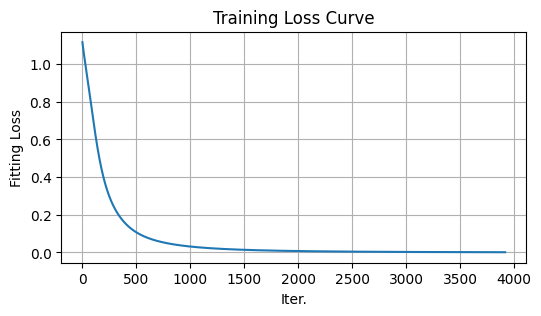

In [25]:
fig = plt.figure(figsize=(6, 3))
plt.plot(clf_MLP.loss_curve_)
plt.grid(True)
plt.title('Training Loss Curve')
plt.xlabel('Iter.')
plt.ylabel('Fitting Loss')
plt.show()

繪製混淆矩陣 Confusion matrix，觀察不同群組的分類表現

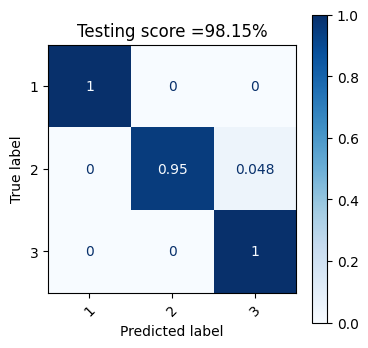

In [27]:
# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# Confusion matrix
title = 'Testing score ={:.2f}%'.format(100*clf_MLP.score(X_test_, y_test))
disp = ConfusionMatrixDisplay.from_estimator(
        clf_MLP,
        X_test_,
        y_test,
        xticks_rotation=45, #'vertical',
        # display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize='true',
        ax = ax
    )
disp.ax_.set_title(title)
# plot_confusion_matrix(clf, X_test, y_test,
#     cmap = plt.cm.Blues, normalize = 'true')  # normalize='false' to show numbers
# plt.title('Testing score ={:.2f}%'.format(100*clf.score(X_test, y_test)))
plt.show() 

<font color=yellow>最佳組合選擇 by GridSearchCV</font>

CV: Cross Validation

In [29]:
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit
from datetime import datetime

# Get the current date and time
now = datetime.now()
# Format the date and time as a string
now_str = now.strftime("%Y_%m_%d_%H_%M_%S")
results_file = 'data/results_' + now_str + '.csv'

opts = dict(tol = 1e-6, max_iter = int(1e6)) # parameters for LogisticRegression
parameters = {'solver':['lbfgs', 'newton-cg', 'sag', 'saga'], \
              'C':[0.1, 1, 10]} # parameters for GridSearchCV
# parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\
#                         'sag','saga']}
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, \
                            random_state=0) # 5-fold CV
grid = GridSearchCV(estimator=LogisticRegression(**opts), \
                param_grid=parameters, cv=cv, 
                scoring=['accuracy','f1_macro'], refit="accuracy")
grid.fit(X_train_, y_train)
cv_logistic = pd.DataFrame(data = grid.cv_results_)
cv_logistic.to_csv(results_file)
print(grid.best_params_)
print(grid.best_score_)
print(grid.best_estimator_)



{'C': 1, 'solver': 'lbfgs'}
0.9894736842105264
LogisticRegression(C=1, max_iter=1000000, tol=1e-06)
